=== Validation set checks ===
Nominal validation rows: 120
Rows with real Ad IDs: 114
Unique real Ad IDs: 114
Duplicated real Ad IDs: 0

Rows with blank / N/A Ad IDs: 6


,validation_row,Platform,Search Term,Ad ID,Human Scam Indicator
112,113,LinkedIn,Secret investment method,N/A,NA
114,115,LinkedIn,Government grant free money,N/A,NA
115,116,LinkedIn,Government grant free money,N/A,NA
119,120,LinkedIn,Join our VIP trading group,N/A,
120,121,LinkedIn,Join our VIP trading group,N/A,
121,122,LinkedIn,Join our VIP trading group,N/A,



Rows with real Ad IDs missing from rubric file: 0
Platform + Ad ID mismatches: 0

=== Usable validation sample ===
Usable validation rows: 114
Unique usable Ad IDs: 114

By platform:
Platform
Meta        60
LinkedIn    54
Name: count, dtype: int64

Human-label distribution:
human_scam
Non-scam    93
Scam        21
Name: count, dtype: int64

=== Human-label distribution by platform ===


human_label_name,Non-scam,Scam,All
Platform,,,
LinkedIn,50,4,54
Meta,43,17,60
All,93,21,114



=== Human-label distribution by platform, with scam share ===


...

,threshold,tp,fp,tn,fn,accuracy,precision,recall,specificity,f1,false_positive_rate,false_negative_rate,predicted_scam_rate
26,26,15,5,88,6,0.903509,0.750000,0.714286,0.946237,0.731707,0.053763,0.285714,0.175439
27,27,15,5,88,6,0.903509,0.750000,0.714286,0.946237,0.731707,0.053763,0.285714,0.175439
25,25,15,6,87,6,0.894737,0.714286,0.714286,0.935484,0.714286,0.064516,0.285714,0.184211
28,28,13,5,88,8,0.885965,0.722222,0.619048,0.946237,0.666667,0.053763,0.380952,0.157895
29,29,13,5,88,8,0.885965,0.722222,0.619048,0.946237,0.666667,0.053763,0.380952,0.157895
30,30,12,4,89,9,0.885965,0.750000,0.571429,0.956989,0.648649,0.043011,0.428571,0.140351
24,24,15,8,85,6,0.877193,0.652174,0.714286,0.913978,0.681818,0.086022,0.285714,0.201754
31,31,11,4,89,10,0.877193,0.733333,0.523810,0.956989,0.611111,0.043011,0.476190,0.131579
32,32,10,3,90,11,0.877193,0.769231,0.476190,0.967742,0.588235,0.032258,0.523810,0.114035
33,33,10,3,90,11,0.877193,0.769231,0.476190,0.967742,0.588235,0.032258,0.523810,0.114035



=== Metrics at chosen threshold = 27 ===


,threshold,tp,fp,tn,fn,accuracy,precision,recall,specificity,f1,false_positive_rate,false_negative_rate,predicted_scam_rate
27,27,15,5,88,6,0.903509,0.75,0.714286,0.946237,0.731707,0.053763,0.285714,0.175439



Confusion matrix:


,Predicted non-scam,Predicted scam
Human non-scam,88,5
Human scam,6,15


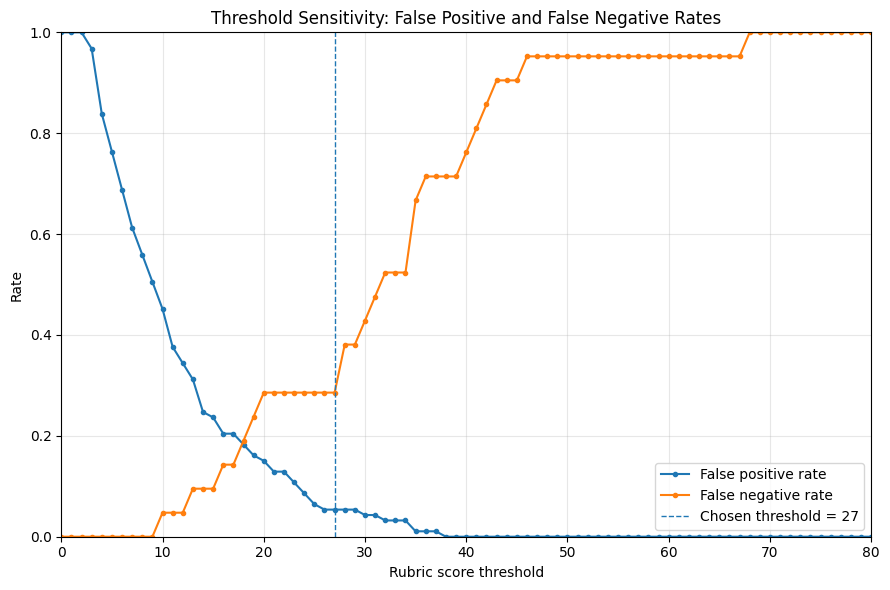

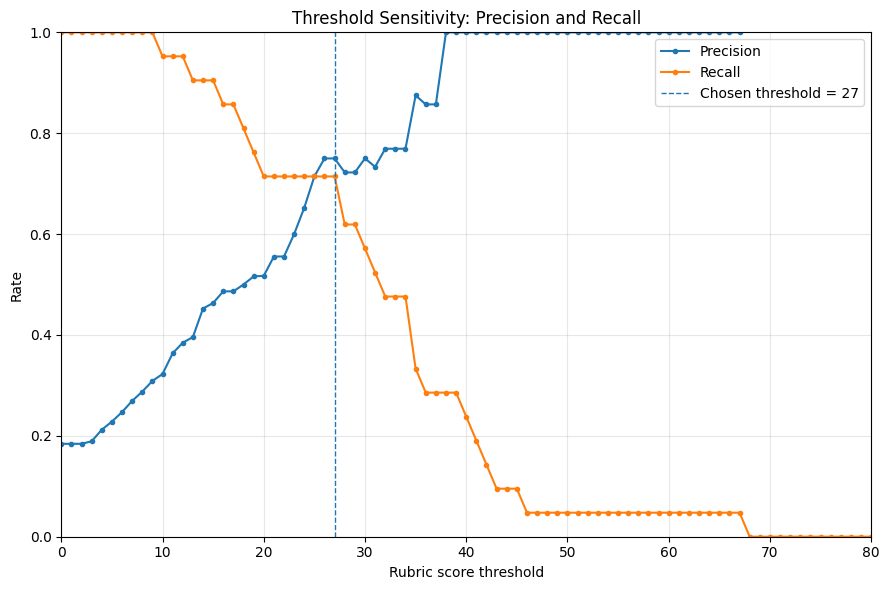

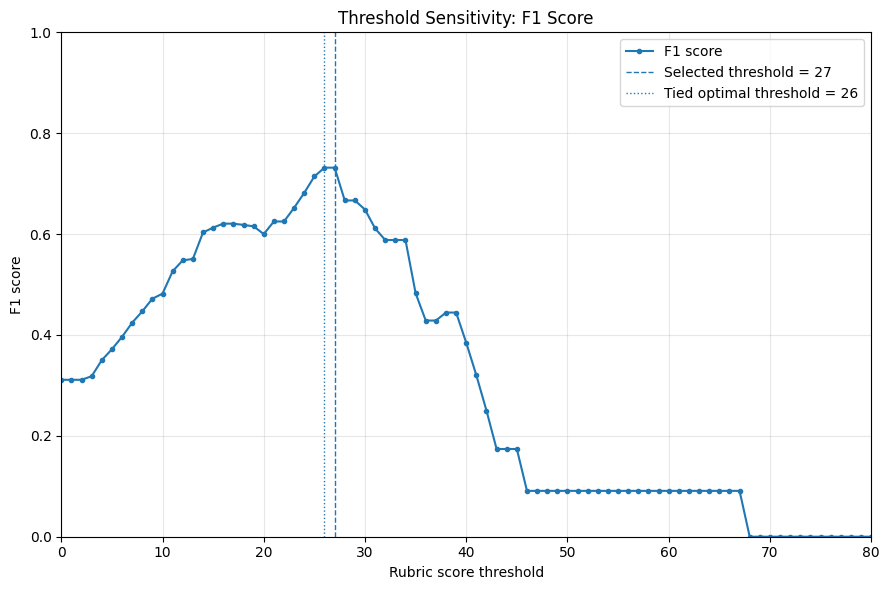

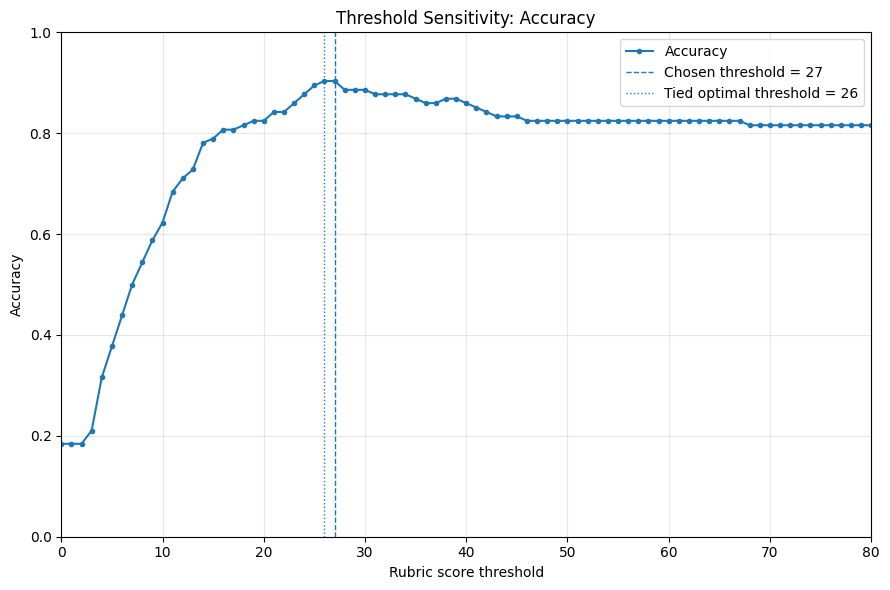

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import re

# =========================
# 1. File paths
# =========================

validation_path = Path("validation_set_vF.csv")
rubric_path = Path("rubric_scores_only_corrected.csv")

output_dir = Path("threshold_outputs")
output_dir.mkdir(exist_ok=True)


# =========================
# 2. Helper functions
# =========================

def normalize_ad_id(x):
    """
    Normalize ad IDs so that string/integer formatting differences do not break matching.
    Treat blank, NA, N/A, etc. as missing.
    """
    s = str(x).strip()

    if s == "" or s.lower() in {"nan", "na", "n/a", "none", "null", "#n/a"}:
        return pd.NA

    # Handles IDs accidentally read as 12345.0
    if re.fullmatch(r"\d+\.0", s):
        s = s[:-2]

    return s


def read_validation_file(path):
    """
    Reads the validation CSV robustly.

    The current validation file has a blank first row, so this function searches
    for the actual header row containing 'Platform' and 'Ad ID'.
    """
    raw = pd.read_csv(path, header=None, dtype=str, keep_default_na=False)

    header_idx = None
    for i, row in raw.iterrows():
        values = [str(x).strip() for x in row.tolist()]
        if "Platform" in values and "Ad ID" in values:
            header_idx = i
            break

    if header_idx is None:
        raise ValueError("Could not find validation header row containing 'Platform' and 'Ad ID'.")

    headers = [
        str(x).strip() if str(x).strip() else f"unnamed_{j}"
        for j, x in enumerate(raw.iloc[header_idx].tolist())
    ]

    validation = raw.iloc[header_idx + 1:].copy()
    validation.columns = headers

    # Actual row number in the CSV / spreadsheet, useful for debugging
    validation["validation_row"] = validation.index + 1

    # Drop fully blank rows, if any
    non_helper_cols = [c for c in validation.columns if c != "validation_row"]
    blank_row_mask = validation[non_helper_cols].apply(
        lambda row: all(str(x).strip() == "" for x in row),
        axis=1
    )
    validation = validation.loc[~blank_row_mask].copy()

    return validation


def safe_divide(num, denom):
    return np.nan if denom == 0 else num / denom


def compute_threshold_metrics(y_true, scores, threshold):
    """
    Computes confusion-matrix metrics for a given threshold.

    Rule:
        predicted_scam = 1 if total_score >= threshold else 0
    """
    y_pred = (scores >= threshold).astype(int)

    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())

    accuracy = safe_divide(tp + tn, tp + fp + tn + fn)
    precision = safe_divide(tp, tp + fp)
    recall = safe_divide(tp, tp + fn)          # Sensitivity / true positive rate
    specificity = safe_divide(tn, tn + fp)    # True negative rate
    f1 = safe_divide(2 * precision * recall, precision + recall) if not (
        pd.isna(precision) or pd.isna(recall) or precision + recall == 0
    ) else np.nan

    fpr = safe_divide(fp, fp + tn)             # False positive rate
    fnr = safe_divide(fn, fn + tp)             # False negative rate

    return {
        "threshold": threshold,
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "specificity": specificity,
        "f1": f1,
        "false_positive_rate": fpr,
        "false_negative_rate": fnr,
        "predicted_scam_rate": safe_divide(tp + fp, tp + fp + tn + fn),
    }


# =========================
# 3. Load files
# =========================

validation = read_validation_file(validation_path)
rubric = pd.read_csv(rubric_path, dtype=str, keep_default_na=False)

required_validation_cols = ["Platform", "Search Term", "Ad ID", "Human Scam Indicator"]
required_rubric_cols = ["platform", "search_type", "search_term", "original_ad_id", "advertiser_name", "total_score"]

missing_validation_cols = [c for c in required_validation_cols if c not in validation.columns]
missing_rubric_cols = [c for c in required_rubric_cols if c not in rubric.columns]

if missing_validation_cols:
    raise ValueError(f"Validation file is missing columns: {missing_validation_cols}")

if missing_rubric_cols:
    raise ValueError(f"Rubric file is missing columns: {missing_rubric_cols}")


# =========================
# 4. Clean IDs and labels
# =========================

validation["ad_id_norm"] = validation["Ad ID"].map(normalize_ad_id)
rubric["ad_id_norm"] = rubric["original_ad_id"].map(normalize_ad_id)

validation["platform_clean"] = validation["Platform"].astype(str).str.strip()
rubric["platform_clean"] = rubric["platform"].astype(str).str.strip()

validation["human_label_raw"] = validation["Human Scam Indicator"].astype(str).str.strip()

# Treat blank / N/A-style labels as missing
validation["human_label_raw"] = validation["human_label_raw"].replace({
    "": pd.NA,
    "NA": pd.NA,
    "N/A": pd.NA,
    "na": pd.NA,
    "n/a": pd.NA,
    "nan": pd.NA,
    "#N/A": pd.NA,
})

# Convert valid human labels to integers
validation["human_scam"] = pd.to_numeric(validation["human_label_raw"], errors="coerce")


# =========================
# 5. Validation quality checks
# =========================

validation_with_id = validation[validation["ad_id_norm"].notna()].copy()

duplicate_rows = validation_with_id[
    validation_with_id.duplicated("ad_id_norm", keep=False)
].sort_values(["ad_id_norm", "validation_row"])

print("=== Validation set checks ===")
print(f"Nominal validation rows: {len(validation)}")
print(f"Rows with real Ad IDs: {len(validation_with_id)}")
print(f"Unique real Ad IDs: {validation_with_id['ad_id_norm'].nunique()}")
print(f"Duplicated real Ad IDs: {duplicate_rows['ad_id_norm'].nunique()}")

if len(duplicate_rows) > 0:
    print("\nDuplicated validation rows:")
    display(duplicate_rows[["validation_row", "Platform", "Search Term", "Ad ID", "Human Scam Indicator"]])

blank_id_rows = validation[validation["ad_id_norm"].isna()].copy()
print(f"\nRows with blank / N/A Ad IDs: {len(blank_id_rows)}")

if len(blank_id_rows) > 0:
    display(blank_id_rows[["validation_row", "Platform", "Search Term", "Ad ID", "Human Scam Indicator"]])


# =========================
# 6. Merge validation set to corrected rubric scores
# =========================

rubric_merge_cols = [
    "ad_id_norm",
    "platform",
    "platform_clean",
    "search_type",
    "search_term",
    "advertiser_name",
    "total_score",
]

merged = validation_with_id.merge(
    rubric[rubric_merge_cols],
    on="ad_id_norm",
    how="left",
    suffixes=("_validation", "_rubric")
)

# Check for validation ads missing from rubric file
missing_from_rubric = merged[merged["total_score"].isna()].copy()
print(f"\nRows with real Ad IDs missing from rubric file: {len(missing_from_rubric)}")

if len(missing_from_rubric) > 0:
    display(missing_from_rubric[["validation_row", "Platform", "Search Term", "Ad ID", "Human Scam Indicator"]])

# Check platform mismatch
platform_mismatch = merged[
    merged["total_score"].notna()
    & (merged["platform_clean_validation"].str.lower() != merged["platform_clean_rubric"].str.lower())
].copy()

print(f"Platform + Ad ID mismatches: {len(platform_mismatch)}")

if len(platform_mismatch) > 0:
    display(platform_mismatch[[
        "validation_row",
        "Platform",
        "platform",
        "Search Term",
        "search_term",
        "Ad ID",
    ]])


# =========================
# 7. Construct usable validation sample
# =========================

merged["total_score"] = pd.to_numeric(merged["total_score"], errors="coerce")

usable = merged[
    merged["total_score"].notna()
    & merged["human_scam"].isin([0, 1])
].copy()

usable["human_scam"] = usable["human_scam"].astype(int)
usable["total_score"] = usable["total_score"].astype(float)

print("\n=== Usable validation sample ===")
print(f"Usable validation rows: {len(usable)}")
print(f"Unique usable Ad IDs: {usable['ad_id_norm'].nunique()}")
print("\nBy platform:")
print(usable["Platform"].value_counts())
print("\nHuman-label distribution:")
print(usable["human_scam"].value_counts().rename(index={0: "Non-scam", 1: "Scam"}))

usable.to_csv(output_dir / "validation_merged_with_corrected_scores.csv", index=False)

# =========================
# 7b. Human-label distribution by VALIDATION platform/search-type design
# =========================

# The validation sheet stores General/Targeted in the first column,
# usually only once at the start of each block. Forward-fill it.
first_col = validation.columns[0]

validation["validation_search_type"] = (
    validation[first_col]
    .replace("", pd.NA)
    .ffill()
    .astype(str)
    .str.strip()
    .str.title()
)

# Bring the validation search type into the usable merged sample
usable = usable.merge(
    validation[["validation_row", "validation_search_type"]],
    on="validation_row",
    how="left"
)

usable["human_label_name"] = usable["human_scam"].map({
    0: "Non-scam",
    1: "Scam"
})

print("\n=== Human-label distribution by platform ===")
platform_label_counts = pd.crosstab(
    usable["Platform"],
    usable["human_label_name"],
    margins=True
)
display(platform_label_counts)

print("\n=== Human-label distribution by platform, with scam share ===")
platform_label_rates = (
    usable
    .groupby("Platform")
    .agg(
        total_ads=("human_scam", "size"),
        scam_ads=("human_scam", "sum"),
        non_scam_ads=("human_scam", lambda x: (x == 0).sum()),
        human_scam_share=("human_scam", "mean")
    )
    .reset_index()
)
display(platform_label_rates)

print("\n=== Human-label distribution by platform + VALIDATION search type ===")
platform_search_label_counts = pd.crosstab(
    [usable["Platform"], usable["validation_search_type"]],
    usable["human_label_name"],
    margins=True
)
display(platform_search_label_counts)

print("\n=== Human-label distribution by platform + VALIDATION search type, with scam share ===")
platform_search_label_rates = (
    usable
    .groupby(["Platform", "validation_search_type"])
    .agg(
        total_ads=("human_scam", "size"),
        scam_ads=("human_scam", "sum"),
        non_scam_ads=("human_scam", lambda x: (x == 0).sum()),
        human_scam_share=("human_scam", "mean")
    )
    .reset_index()
)
display(platform_search_label_rates)

# =========================
# 8. Threshold sweep from 0 to 80
# =========================

y_true = usable["human_scam"].to_numpy()
scores = usable["total_score"].to_numpy()

thresholds = range(0, 81)

metrics = [
    compute_threshold_metrics(y_true, scores, threshold)
    for threshold in thresholds
]

threshold_metrics = pd.DataFrame(metrics)

# Optional: identify strongest thresholds by F1 and accuracy
best_by_f1 = threshold_metrics.sort_values(
    ["f1", "accuracy", "recall", "precision"],
    ascending=False
).head(10)

best_by_accuracy = threshold_metrics.sort_values(
    ["accuracy", "f1", "recall", "precision"],
    ascending=False
).head(10)

print("\n=== Top thresholds by F1 ===")
display(best_by_f1)

print("\n=== Top thresholds by accuracy ===")
display(best_by_accuracy)

threshold_metrics.to_csv(output_dir / "threshold_sensitivity_metrics.csv", index=False)


# =========================
# 9. Save final-threshold confusion matrix helper
# =========================

# Change this once you choose the final threshold.
# Based on the earlier run, 26 or 27 were likely candidates, but rerun this after your new validation edits.
chosen_threshold = 27

chosen_row = threshold_metrics.loc[
    threshold_metrics["threshold"] == chosen_threshold
].copy()

print(f"\n=== Metrics at chosen threshold = {chosen_threshold} ===")
display(chosen_row)

usable[f"predicted_scam_threshold_{chosen_threshold}"] = (
    usable["total_score"] >= chosen_threshold
).astype(int)

usable.to_csv(
    output_dir / f"validation_predictions_threshold_{chosen_threshold}.csv",
    index=False
)

confusion_matrix = pd.DataFrame({
    "Predicted non-scam": [
        int(((usable["human_scam"] == 0) & (usable[f"predicted_scam_threshold_{chosen_threshold}"] == 0)).sum()),
        int(((usable["human_scam"] == 1) & (usable[f"predicted_scam_threshold_{chosen_threshold}"] == 0)).sum()),
    ],
    "Predicted scam": [
        int(((usable["human_scam"] == 0) & (usable[f"predicted_scam_threshold_{chosen_threshold}"] == 1)).sum()),
        int(((usable["human_scam"] == 1) & (usable[f"predicted_scam_threshold_{chosen_threshold}"] == 1)).sum()),
    ],
}, index=["Human non-scam", "Human scam"])

print("\nConfusion matrix:")
display(confusion_matrix)

confusion_matrix.to_csv(output_dir / f"confusion_matrix_threshold_{chosen_threshold}.csv")


# =========================
# Figure 1. False positives and false negatives across thresholds
# =========================

plt.figure(figsize=(9, 6))

plt.plot(
    threshold_metrics["threshold"],
    threshold_metrics["false_positive_rate"],
    marker="o",
    markersize=3,
    label="False positive rate"
)

plt.plot(
    threshold_metrics["threshold"],
    threshold_metrics["false_negative_rate"],
    marker="o",
    markersize=3,
    label="False negative rate"
)

plt.axvline(
    chosen_threshold,
    linestyle="--",
    linewidth=1,
    label=f"Chosen threshold = {chosen_threshold}"
)

plt.xlabel("Rubric score threshold")
plt.ylabel("Rate")
plt.title("Threshold Sensitivity: False Positive and False Negative Rates")
plt.xlim(0, 80)
plt.ylim(0, 1)
plt.xticks(range(0, 81, 10))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(output_dir / "threshold_sensitivity_fpr_fnr.png", dpi=300)
plt.show()


# =========================
# Figure 2. Precision and recall across thresholds
# =========================

plt.figure(figsize=(9, 6))

plt.plot(
    threshold_metrics["threshold"],
    threshold_metrics["precision"],
    marker="o",
    markersize=3,
    label="Precision"
)

plt.plot(
    threshold_metrics["threshold"],
    threshold_metrics["recall"],
    marker="o",
    markersize=3,
    label="Recall"
)

plt.axvline(
    chosen_threshold,
    linestyle="--",
    linewidth=1,
    label=f"Chosen threshold = {chosen_threshold}"
)

plt.xlabel("Rubric score threshold")
plt.ylabel("Rate")
plt.title("Threshold Sensitivity: Precision and Recall")
plt.xlim(0, 80)
plt.ylim(0, 1)
plt.xticks(range(0, 81, 10))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(output_dir / "threshold_sensitivity_precision_recall.png", dpi=300)
plt.show()

# =========================
# Figure 3. F1 score across thresholds
# =========================

chosen_threshold = 27

# For plotting only: when no ads are predicted scam, F1 is undefined.
# We plot those cases as 0 so the figure runs through threshold 80.
threshold_metrics["f1_plot"] = threshold_metrics["f1"].fillna(0)

plt.figure(figsize=(9, 6))

plt.plot(
    threshold_metrics["threshold"],
    threshold_metrics["f1_plot"],
    marker="o",
    markersize=3,
    label="F1 score"
)

plt.axvline(
    chosen_threshold,
    linestyle="--",
    linewidth=1,
    label=f"Selected threshold = {chosen_threshold}"
)

# Mark the tied optimal threshold band
plt.axvline(
    26,
    linestyle=":",
    linewidth=1,
    label="Tied optimal threshold = 26"
)

plt.xlabel("Rubric score threshold")
plt.ylabel("F1 score")
plt.title("Threshold Sensitivity: F1 Score")
plt.xlim(0, 80)
plt.ylim(0, 1)
plt.xticks(range(0, 81, 10))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(output_dir / "figure_3_f1_score_by_threshold.png", dpi=300)
plt.show()

# =========================
# Figure 4. Accuracy across thresholds
# =========================

chosen_threshold = 27

plt.figure(figsize=(9, 6))

plt.plot(
    threshold_metrics["threshold"],
    threshold_metrics["accuracy"],
    marker="o",
    markersize=3,
    label="Accuracy"
)

plt.axvline(
    chosen_threshold,
    linestyle="--",
    linewidth=1,
    label=f"Chosen threshold = {chosen_threshold}"
)

# Mark the tied optimal threshold band
plt.axvline(
    26,
    linestyle=":",
    linewidth=1,
    label="Tied optimal threshold = 26"
)

plt.xlabel("Rubric score threshold")
plt.ylabel("Accuracy")
plt.title("Threshold Sensitivity: Accuracy")
plt.xlim(0, 80)
plt.ylim(0, 1)
plt.xticks(range(0, 81, 10))
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(output_dir / "figure_4_accuracy_by_threshold.png", dpi=300)
plt.show()